In [ ]:
# !pip install earthengine-api geemap geopandas

In [1]:
import ee
import geemap
import pandas as pd
import geopandas as gpd
import json
from pathlib import Path

### *Reminder to swap to service account when integrating into app

In [2]:
# only if first run or expired token
ee.Authenticate()

GEE_PROJECT = "ee-klewtak"
ee.Initialize(project=GEE_PROJECT)

In [3]:
# prototype hard coded sites
site_data = [
    {"site_id": "point_1", "name": "Site_A", "longitude": -91.04, "latitude": 29.47},
    {"site_id": "point_2", "name": "Site_B", "longitude": -90.23, "latitude": 29.62},
    {"site_id": "point_3", "name": "Site_C", "longitude": -89.83, "latitude": 29.49},
]

sites_df = pd.DataFrame(site_data)
sites_gdf = gpd.GeoDataFrame(
    sites_df,
    geometry=gpd.points_from_xy(sites_df.longitude, sites_df.latitude),
    crs="EPSG:4326",
)

print(f"{len(sites_gdf)} sites loaded")
sites_gdf.head()

3 sites loaded


,site_id,name,longitude,latitude,geometry
0,point_1,Site_A,-91.04,29.47,POINT (-91.04 29.47)
1,point_2,Site_B,-90.23,29.62,POINT (-90.23 29.62)
2,point_3,Site_C,-89.83,29.49,POINT (-89.83 29.49)


In [ ]:
# eventually load sites from CSV
# SITES_CSV = r"path/CCN_sites.csv"
# sites_df = pd.read_csv(SITES_CSV)
#
# compute center points for extraction
# sites_df["latitude"] = (sites_df["site_latitude_min"]  + sites_df["site_latitude_max"]) / 2
# sites_df["longitude"] = (sites_df["site_longitude_min"] + sites_df["site_longitude_max"]) / 2
# sites_df = sites_df.dropna(subset=["latitude", "longitude"])
#
# sites_gdf = gpd.GeoDataFrame(
#     sites_df,
#     geometry=gpd.points_from_xy(sites_df["longitude"], sites_df["latitude"]),
#     crs="EPSG:4326",
# )

In [4]:
# convert gdf to ee.FeatureCollection
def gdf_to_ee_fc(gdf: gpd.GeoDataFrame) -> ee.FeatureCollection:
    """Convert a GeoDataFrame of points to an ee.FeatureCollection,
    preserving all attribute columns as properties."""
    features = []
    for _, row in gdf.iterrows():
        geom = ee.Geometry.Point([row.geometry.x, row.geometry.y])
        props = row.drop("geometry").to_dict()
        # ee properties must be serializable; convert numpy types
        props = {k: (v.item() if hasattr(v, "item") else v) for k, v in props.items()}
        features.append(ee.Feature(geom, props))
    return ee.FeatureCollection(features)


points_fc = gdf_to_ee_fc(sites_gdf)
print("ee.FeatureCollection size:", points_fc.size().getInfo())

ee.FeatureCollection size: 3


Querying EMIT:

In [ ]:
EMIT_COLLECTION = "NASA/EMIT/L2A/RFL"
DATE_START = "2023-01-01"
DATE_END = "2025-01-01"

emit_col = ee.ImageCollection(EMIT_COLLECTION).filterDate(DATE_START, DATE_END).filterBounds(points_fc)

n_images = emit_col.size().getInfo()
print(f"EMIT scenes matching filters: {n_images}")

EMIT scenes matching filters: 28


In [6]:
# metadata
def get_collection_info(collection: ee.ImageCollection) -> pd.DataFrame:
    """Pull date, scene ID, and cloud cover for every image in a collection."""
    info = collection.aggregate_array("system:index").getInfo()
    dates = collection.aggregate_array("system:time_start").getInfo()
    df = pd.DataFrame({"scene_id": info, "timestamp_ms": dates})
    df["date"] = pd.to_datetime(df["timestamp_ms"], unit="ms")
    return df.sort_values("date").reset_index(drop=True)


scenes_df = get_collection_info(emit_col)
print(f"Date range: {scenes_df['date'].min()} → {scenes_df['date'].max()}")
scenes_df.head(10)

Date range: 2023-02-19 18:58:54 → 2024-12-17 18:53:21


,scene_id,timestamp_ms,date
0,EMIT_L2A_RFL_001_20230219T185854_2305012_017,1676833134000,2023-02-19 18:58:54
1,EMIT_L2A_RFL_001_20230403T172921_2309312_002,1680542961000,2023-04-03 17:29:21
2,EMIT_L2A_RFL_001_20230422T182827_2311212_018,1682188107000,2023-04-22 18:28:27
3,EMIT_L2A_RFL_001_20230629T153357_2318010_008,1688052837000,2023-06-29 15:33:57
4,EMIT_L2A_RFL_001_20230929T183606_2327212_002,1696012566000,2023-09-29 18:36:06
5,EMIT_L2A_RFL_001_20231003T170036_2327611_002,1696352436000,2023-10-03 17:00:36
6,EMIT_L2A_RFL_001_20231222T174800_2335612_015,1703267280000,2023-12-22 17:48:00
7,EMIT_L2A_RFL_001_20231226T161215_2336011_004,1703607135000,2023-12-26 16:12:15
8,EMIT_L2A_RFL_001_20240225T161236_2405611_018,1708877556000,2024-02-25 16:12:36
9,EMIT_L2A_RFL_001_20240331T174825_2409112_004,1711907305000,2024-03-31 17:48:25


Cloud masking:

In [7]:
def mask_emit_clouds(img: ee.Image) -> ee.Image:
    """Mask cloudy pixels using the dilated_cloud_flag band.
    Flag == 0 indicates clear sky."""
    cloud_mask = img.select("dilated_cloud_flag").eq(0)
    return img.updateMask(cloud_mask)


# apply mask and build a mosaic composite
emit_masked = emit_col.map(mask_emit_clouds)
emit_mosaic = emit_masked.mosaic()

# verify band list
band_names = emit_mosaic.bandNames().getInfo()
print(f"Total bands in mosaic: {len(band_names)}")
print(f"First 10 bands: {band_names[:10]}")
print(f"Last 5 bands:  {band_names[-5:]}")

Total bands in mosaic: 579
First 10 bands: ['reflectance_0', 'reflectance_1', 'reflectance_2', 'reflectance_3', 'reflectance_4', 'reflectance_5', 'reflectance_6', 'reflectance_7', 'reflectance_8', 'reflectance_9']
Last 5 bands:  ['spacecraft_flag', 'dilated_cloud_flag', 'AOD550', 'H2O', 'aggregate_flag']


Client-side sampling:

In [8]:
sampled_df = geemap.ee_to_df(
    emit_mosaic.sampleRegions(
        collection=points_fc,
        scale=60,
        geometries=True,
        tileScale=4,
    )
)

print(f"DataFrame shape: {sampled_df.shape}")
sampled_df.head()

DataFrame shape: (3, 583)


,AOD550,H2O,aggregate_flag,cirrus_flag,cloud_flag,dilated_cloud_flag,elev,latitude,longitude,name,...,reflectance_uncertainity_93,reflectance_uncertainity_94,reflectance_uncertainity_95,reflectance_uncertainity_96,reflectance_uncertainity_97,reflectance_uncertainity_98,reflectance_uncertainity_99,site_id,spacecraft_flag,water_flag
0,0.123610,2.572254,0,0,0,0,-25.218046,29.47,-91.04,Site_A,...,0.001815,0.001863,0.001930,0.002035,0.002149,0.002219,0.002346,point_1,0,0
1,0.834112,0.721947,1,0,0,0,-26.469259,29.62,-90.23,Site_B,...,0.001304,0.001311,0.001309,0.001339,0.001409,0.001619,0.002010,point_2,0,0
2,0.662122,5.522142,1,0,0,0,-25.846853,29.49,-89.83,Site_C,...,0.001449,0.001477,0.001552,0.001768,0.002085,0.002757,0.003830,point_3,0,0


In [9]:
refl_cols = [c for c in sampled_df.columns if c.startswith("reflectance_")]
meta_cols = [c for c in sampled_df.columns if c not in refl_cols]

print(f"Reflectance bands extracted: {len(refl_cols)}")
print(f"Metadata columns: {meta_cols}")

Reflectance bands extracted: 570
Metadata columns: ['AOD550', 'H2O', 'aggregate_flag', 'cirrus_flag', 'cloud_flag', 'dilated_cloud_flag', 'elev', 'latitude', 'longitude', 'name', 'site_id', 'spacecraft_flag', 'water_flag']


In [ ]:
# wavelength lookup
first_img = ee.Image(emit_col.first())

try:
    wavelengths = first_img.get("wavelengths").getInfo()
    print(f"Retrieved {len(wavelengths)} center wavelengths from image metadata")
except Exception:
    import numpy as np

    wavelengths = np.linspace(381, 2493, len(refl_cols)).tolist()
    print(f"Using approximate wavelengths ({len(wavelengths)} bands)")

band_wavelength_map = {f"reflectance_{i}": wl for i, wl in enumerate(wavelengths)}

print(f"Band 0 → {wavelengths[0]:.1f} nm")
print(f"Band {len(wavelengths)-1} → {wavelengths[-1]:.1f} nm")

Using approximate wavelengths (570 bands)
Band 0 → 381.0 nm
Band 569 → 2493.0 nm


In [11]:
spectra_long = sampled_df.melt(
    id_vars=meta_cols,
    value_vars=refl_cols,
    var_name="band",
    value_name="reflectance",
)
spectra_long["wavelength_nm"] = spectra_long["band"].map(band_wavelength_map)

print(f"Long-format shape: {spectra_long.shape}")
spectra_long.head()

Long-format shape: (1710, 16)


,AOD550,H2O,aggregate_flag,cirrus_flag,cloud_flag,dilated_cloud_flag,elev,latitude,longitude,name,site_id,spacecraft_flag,water_flag,band,reflectance,wavelength_nm
0,0.123610,2.572254,0,0,0,0,-25.218046,29.47,-91.04,Site_A,point_1,0,0,reflectance_0,0.008977,381.000000
1,0.834112,0.721947,1,0,0,0,-26.469259,29.62,-90.23,Site_B,point_2,0,0,reflectance_0,0.018907,381.000000
2,0.662122,5.522142,1,0,0,0,-25.846853,29.49,-89.83,Site_C,point_3,0,0,reflectance_0,0.011937,381.000000
3,0.123610,2.572254,0,0,0,0,-25.218046,29.47,-91.04,Site_A,point_1,0,0,reflectance_1,0.014114,384.711775
4,0.834112,0.721947,1,0,0,0,-26.469259,29.62,-90.23,Site_B,point_2,0,0,reflectance_1,0.019181,384.711775


In [ ]:
# eventually merge with CCN submission data
# CCN_FILE = "path/ccn_submission_data.csv"
# ccn_df = pd.read_csv(CCN_FILE)
#
# merged = spectra_long.merge(
#     ccn_df,
#     left_on="site_id",
#     right_on="site_id",
#     how="inner",
# )
# print(f"Merged records: {len(merged)}")
# merged.head()

Export:

In [12]:
OUT_DIR = Path("outputs/local_emit_extract")
OUT_DIR.mkdir(exist_ok=True)

# wide format — one row per site, columns = bands
sampled_df.to_csv(OUT_DIR / "emit_spectra_wide.csv", index=False)

# long format — one row per site × band
spectra_long.to_csv(OUT_DIR / "emit_spectra_long.csv", index=False)

print(f"Saved to {OUT_DIR.resolve()}")

Saved to /home/klewtak/NASA/CCN-Data-Library/scripts/4_capstone/EO/outputs/local_emit_extract


Example plot:

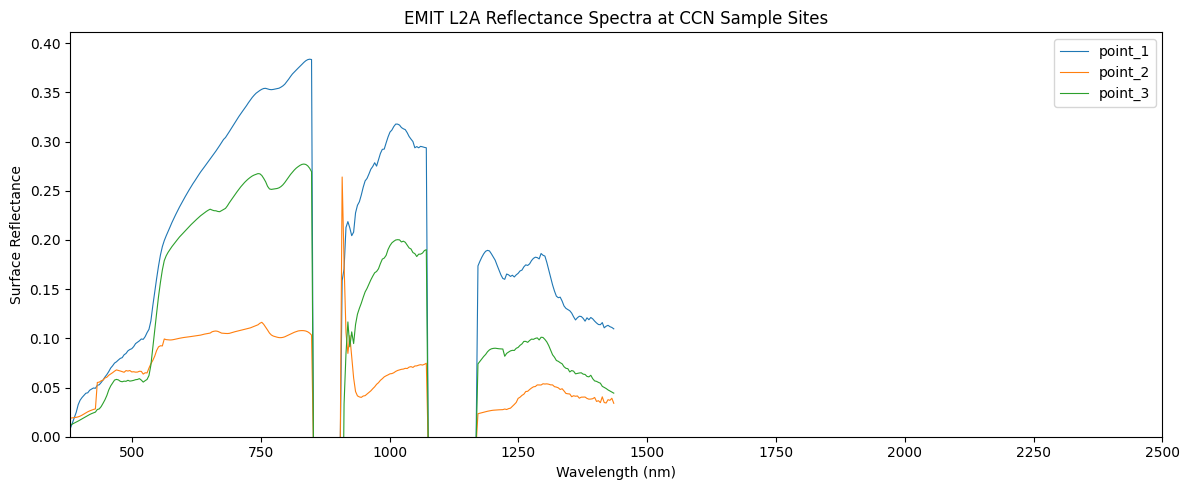

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

for site_id, group in spectra_long.groupby("site_id"):
    group_sorted = group.sort_values("wavelength_nm")
    ax.plot(
        group_sorted["wavelength_nm"],
        group_sorted["reflectance"],
        label=site_id,
        linewidth=0.8,
    )

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Surface Reflectance")
ax.set_title("EMIT L2A Reflectance Spectra at CCN Sample Sites")
ax.legend()
ax.set_xlim(380, 2500)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

In [17]:
Map = geemap.Map(center=[29.5, -90.3], zoom=8)

viz_params = {
    "bands": ["reflectance_51"],
    "min": 0,
    "max": 0.4,
}
Map.addLayer(emit_mosaic, viz_params, "EMIT Reflectance (band 51)")
Map.addLayer(points_fc, {"color": "red"}, "Sample Sites")

false_color = {
    "bands": ["reflectance_150", "reflectance_51", "reflectance_30"],
    "min": 0,
    "max": 0.35,
}
Map.addLayer(emit_mosaic, false_color, "EMIT False Color (SWIR/NIR/Red)", shown=False)

Map.add_layer_control()
Map

Map(center=[29.5, -90.3], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

Optional extraction:

In [ ]:
def extract_single_scene(img: ee.Image) -> ee.FeatureCollection:
    """Sample a single EMIT image at all point locations,
    and attach the image date as a property."""
    date_str = img.date().format("YYYY-MM-dd")
    sampled = img.sampleRegions(
        collection=points_fc,
        scale=60,
        geometries=True,
        tileScale=4,
    )
    return sampled.map(lambda f: f.set("image_date", date_str))


per_scene_fc = emit_masked.limit(5).map(extract_single_scene).flatten()
per_scene_df = geemap.ee_to_df(per_scene_fc)
print(f"Per-scene records: {per_scene_df.shape}")
per_scene_df.head()

Per-scene records: (4, 584)


,AOD550,H2O,aggregate_flag,cirrus_flag,cloud_flag,dilated_cloud_flag,elev,image_date,latitude,longitude,...,reflectance_uncertainity_93,reflectance_uncertainity_94,reflectance_uncertainity_95,reflectance_uncertainity_96,reflectance_uncertainity_97,reflectance_uncertainity_98,reflectance_uncertainity_99,site_id,spacecraft_flag,water_flag
0,0.162193,1.565356,0,0,0,0,-25.176142,2023-02-19,29.47,-91.04,...,0.001309,0.001320,0.001334,0.001409,0.001541,0.001872,0.002447,point_1,0,0
1,0.278851,2.489896,1,0,0,0,-26.469885,2023-02-19,29.62,-90.23,...,0.001221,0.001166,0.001121,0.001095,0.001084,0.001079,0.001098,point_2,0,1
2,0.741955,2.815016,1,0,0,0,-24.038717,2023-04-03,29.49,-89.83,...,0.001263,0.001278,0.001313,0.001435,0.001630,0.002073,0.002807,point_3,0,0
3,0.199836,1.295735,0,0,0,0,-26.223074,2023-04-22,29.47,-91.04,...,0.001218,0.001225,0.001254,0.001384,0.001596,0.002097,0.002879,point_1,0,0
